# MAT vs CSV dataset demo

This notebook demonstrates the difference between the two dataset formats used in this project:

- **CSV files** store coordinates plus a measured pitch angle `Angle (α′)`.
- **MAT files** store detected line segments, which are converted directly into a line-field orientation `phi`.

In short: CSV -> pitch angle first; MAT -> line field first.

In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "vf_exports").exists() and (path / "python_notebooks").exists():
            return path
    return start


ROOT = find_repo_root()
ROOT

PosixPath('/Users/rishabhkumar/.codex/worktrees/124b/spiral-chirals')

## 1. CSV: pitch-angle dataset

The CSV has one row per sampled ring coordinate. Its key measured quantity is `Angle (α′)`, the local pitch angle relative to the radial direction at that coordinate.

To turn that pitch angle into a global plotted direction, we add the spatial polar angle `theta = atan2(y, x)`.

In [2]:
csv_path = ROOT / "vf_exports" / "Front_EE1_1_3000x_rings_coords.csv"
if not csv_path.exists():
    csv_path = ROOT / "vf_exports" / "Front_EE-1_1_3000x_rings_coords.csv"

df = pd.read_csv(csv_path, encoding="utf-8-sig")
df = df.iloc[:-1].copy()  # the existing notebooks drop the final summary/footer row

print(csv_path.relative_to(ROOT))
display(df.head())
print("Columns:", list(df.columns))
print("Rows:", len(df))

vf_exports/Front_EE1_1_3000x_rings_coords.csv


,Ring,Coordinate,Angle (α′),Pattern
0,1,"(6.00, 0.00)",83.01,Anticlockwise
1,1,"(0.00, -6.00)",-2.15,Clockwise
2,1,"(-6.00, 0.00)",-82.12,Clockwise
3,1,"(0.00, 6.00)",-5.84,Clockwise
4,2,"(35.00, 0.00)",45.18,Anticlockwise


Columns: ['Ring', 'Coordinate', 'Angle (α′)', 'Pattern']
Rows: 136


In [3]:
def parse_coord(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return float(value[0]), float(value[1])
    try:
        parsed = ast.literal_eval(str(value))
        return float(parsed[0]), float(parsed[1])
    except Exception:
        parts = str(value).strip("()[]").split(",")
        return float(parts[0]), float(parts[1])


coords = np.array(df["Coordinate"].apply(parse_coord).tolist(), dtype=float)
x, y = coords[:, 0], coords[:, 1]

# CSV angle: local pitch angle alpha-prime, in degrees.
alpha_deg = df["Angle (α′)"].to_numpy(dtype=float)
alpha_rad = np.deg2rad(alpha_deg)

# Convert local pitch angle to global line/vector direction.
theta = np.arctan2(y, x)
phi_from_csv = theta + alpha_rad
u_csv = np.cos(phi_from_csv)
v_csv = np.sin(phi_from_csv)

csv_demo = pd.DataFrame({
    "x": x,
    "y": y,
    "theta_deg = atan2(y,x)": np.degrees(theta),
    "pitch_alpha_deg_from_csv": alpha_deg,
    "global_phi_deg = theta + alpha": np.degrees(phi_from_csv),
})
display(csv_demo.head(10))

,x,y,"theta_deg = atan2(y,x)",pitch_alpha_deg_from_csv,global_phi_deg = theta + alpha
0,6.0,0.0,0.0,83.01,83.01
1,0.0,-6.0,-90.0,-2.15,-92.15
2,-6.0,0.0,180.0,-82.12,97.88
3,0.0,6.0,90.0,-5.84,84.16
4,35.0,0.0,0.0,45.18,45.18
5,25.0,-25.0,-45.0,35.91,-9.09
6,0.0,-35.0,-90.0,73.96,-16.04
7,-25.0,25.0,135.0,-29.01,105.99
8,0.0,35.0,90.0,8.55,98.55
9,25.0,25.0,45.0,45.49,90.49


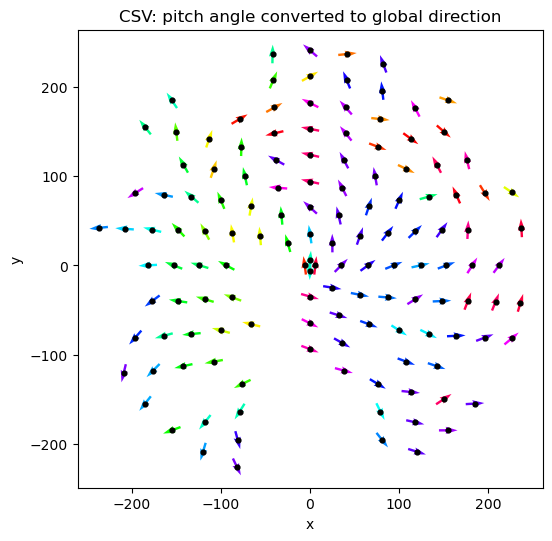

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(x, y, u_csv, v_csv, alpha_deg, cmap="hsv", pivot="mid", scale=25)
ax.scatter(x, y, s=12, color="black")
ax.set_aspect("equal", "box")
ax.set_title("CSV: pitch angle converted to global direction")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

## 2. MAT: line-field dataset

The MAT loader used by the cleaned comparison expects `arrow_segments.mat` files containing a variable named `perpendicular_segments`.

Each row is interpreted as one detected line segment:

`[x1, y1, x2, y2]`

The midpoint gives the observation location. The endpoint difference gives the observed line-field orientation directly.

In [5]:
mat_paths = sorted(ROOT.glob("data/**/arrow_segments.mat"))

if mat_paths and loadmat is not None:
    mat_path = mat_paths[0]
    mat = loadmat(mat_path)
    segments = np.asarray(mat["perpendicular_segments"], dtype=float)
    print("Loaded real MAT file:", mat_path.relative_to(ROOT))
else:
    mat_path = None
    # The raw MAT files are not present in this worktree, so this tiny array mimics
    # the expected MAT variable shape: [x1, y1, x2, y2] per detected line segment.
    segments = np.array([
        [10, 10, 30, 10],
        [40, 15, 55, 30],
        [25, 45, 25, 70],
        [60, 65, 80, 50],
    ], dtype=float)
    print("No arrow_segments.mat files found here; using a synthetic MAT-like example.")

segments = segments[np.isfinite(segments).all(axis=1)]
print("segments shape:", segments.shape)
pd.DataFrame(segments[:8], columns=["x1", "y1", "x2", "y2"])

No arrow_segments.mat files found here; using a synthetic MAT-like example.
segments shape: (4, 4)


,x1,y1,x2,y2
0,10.0,10.0,30.0,10.0
1,40.0,15.0,55.0,30.0
2,25.0,45.0,25.0,70.0
3,60.0,65.0,80.0,50.0


In [6]:
x1, y1, x2, y2 = segments[:, 0], segments[:, 1], segments[:, 2], segments[:, 3]

# MAT data: endpoint geometry is already a global line-field observation.
xc = 0.5 * (x1 + x2)
yc = 0.5 * (y1 + y2)
dx = x2 - x1
dy = -(y2 - y1)  # flip image y-axis into model coordinates, matching the scripts
phi_from_mat = np.arctan2(dy, dx)
u_mat = np.cos(phi_from_mat)
v_mat = np.sin(phi_from_mat)

mat_demo = pd.DataFrame({
    "x_mid": xc,
    "y_mid": yc,
    "dx": dx,
    "dy_model": dy,
    "global_phi_deg_from_segment": np.degrees(phi_from_mat),
})
display(mat_demo.head(10))

,x_mid,y_mid,dx,dy_model,global_phi_deg_from_segment
0,20.0,10.0,20.0,-0.0,-0.000000
1,47.5,22.5,15.0,-15.0,-45.000000
2,25.0,57.5,0.0,-25.0,-90.000000
3,70.0,57.5,20.0,15.0,36.869898


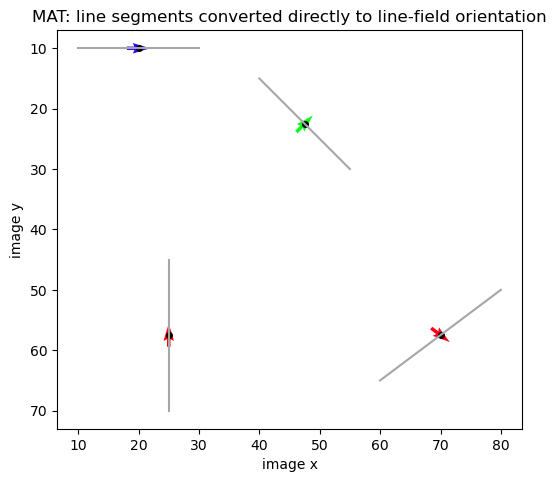

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the raw detected segments.
for row in segments[:200]:
    ax.plot([row[0], row[2]], [row[1], row[3]], color="0.65", linewidth=1.5)

# Overlay midpoint orientations as headless-looking quivers.
ax.quiver(xc, yc, u_mat, -v_mat, np.degrees(phi_from_mat), cmap="hsv", pivot="mid", scale=20)
ax.scatter(xc, yc, s=16, color="black")
ax.set_aspect("equal", "box")
ax.invert_yaxis()
ax.set_title("MAT: line segments converted directly to line-field orientation")
ax.set_xlabel("image x")
ax.set_ylabel("image y")
plt.show()

## Takeaway

| File type | What is stored | What the model derives |
|---|---|---|
| `.csv` | ring coordinate plus local pitch angle `Angle (α′)` | global direction `phi = theta + alpha` |
| `.mat` | detected segment endpoints `[x1, y1, x2, y2]` | midpoint location plus global line-field orientation `phi = atan2(dy, dx)` |

So the CSV starts with **pitch angle** and builds a line/vector field from it. The MAT starts with the **line field** itself.